In [ ]:
!nvidia-smi

/bin/bash: line 1: nvidia-smi: command not found


In [1]:
import numpy as np
from PIL import Image
import glob as gl
import matplotlib.pyplot as plt
import torchvision.transforms.v2 as transforms
import torch
from torch.utils.data import TensorDataset, DataLoader

In [2]:
! pip install kaggle


[notice] A new release of pip is available: 24.0 -> 25.0.1
[notice] To update, run: C:\Users\anmol\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [3]:
! mkdir ~/.kaggle

The syntax of the command is incorrect.


In [4]:
! cp kaggle.json ~/.kaggle/

'cp' is not recognized as an internal or external command,
operable program or batch file.


In [5]:
! chmod 600 ~/.kaggle/kaggle.json

'chmod' is not recognized as an internal or external command,
operable program or batch file.


In [6]:
! kaggle datasets download prashant268/chest-xray-covid19-pneumonia

Dataset URL: https://www.kaggle.com/datasets/prashant268/chest-xray-covid19-pneumonia
License(s): unknown
chest-xray-covid19-pneumonia.zip: Skipping, found more recently modified local copy (use --force to force download)


In [7]:
! unzip chest-xray-covid19-pneumonia.zip

'unzip' is not recognized as an internal or external command,
operable program or batch file.


In [8]:
! kaggle datasets download paultimothymooney/chest-xray-pneumonia

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
chest-xray-pneumonia.zip: Skipping, found more recently modified local copy (use --force to force download)


In [9]:
! unzip chest-xray-pneumonia.zip

'unzip' is not recognized as an internal or external command,
operable program or batch file.


In [10]:
image_size = 32

In [11]:
def build_dataset(path):
  images = gl.glob(path)
  dataset = []
  for image in images:

    img = transforms.Resize((image_size, image_size))(Image.open(image))
    img = transforms.Grayscale(1)(img)
    dataset.append(img)
  return dataset

In [12]:
def abc(img):
  img = transforms.Resize((image_size, image_size))(img)
  img = transforms.ToTensor()(img)
  img = transforms.Normalize(mean=[0.5], std=[0.5])(img)
  return img

In [13]:
DATASET_1_TRAIN_PATH_COVID='Data/train/COVID19/*'
DATASET_1_TRAIN_PATH_NORMAL='Data/train/NORMAL/*'
DATASET_1_TRAIN_PATH_PNEUMONIA='Data/train/PNEUMONIA/*'
DATASET_2_TRAIN_PATH_NORMAL='chest_xray/train/NORMAL/*'
DATASET_2_TRAIN_PATH_PNEUMONIA='chest_xray/train/PNEUMONIA/*'
DATASET_1_TEST_PATH_COVID='Data/test/COVID19/*'
DATASET_1_TEST_PATH_NORMAL='Data/test/NORMAL/*'
DATASET_1_TEST_PATH_PNEUMONIA='Data/test/PNEUMONIA/*'
DATASET_2_TEST_PATH_NORMAL='chest_xray/test/NORMAL/*'
DATASET_2_TEST_PATH_PNEUMONIA='chest_xray/test/PNEUMONIA/*'
DATASET_2_VAL_PATH_NORMAL='chest_xray/val/NORMAL/*'
DATASET_2_VAL_PATH_PNEUMONIA='chest_xray/val/PNEUMONIA/*'

In [14]:
# one-hot encoding
Classes = {
    'NORMAL':[1,0,0],
    'COVID19':[0,1,0],
    'PNEUMONIA':[0,0,1]
}

In [15]:
dataset_1_train_1 = build_dataset(DATASET_1_TRAIN_PATH_COVID)
dataset_1_train_2 = build_dataset(DATASET_1_TRAIN_PATH_NORMAL)
dataset_1_train_3 = build_dataset(DATASET_1_TRAIN_PATH_PNEUMONIA)
dataset_2_train_1 = build_dataset(DATASET_2_TRAIN_PATH_NORMAL)
dataset_2_train_2 = build_dataset(DATASET_2_TRAIN_PATH_PNEUMONIA)
dataset_1_test_1 = build_dataset(DATASET_1_TEST_PATH_COVID)
dataset_1_test_2 = build_dataset(DATASET_1_TEST_PATH_NORMAL)
dataset_1_test_3 = build_dataset(DATASET_1_TEST_PATH_PNEUMONIA)
dataset_2_test_1 = build_dataset(DATASET_2_TEST_PATH_NORMAL)
dataset_2_test_2 = build_dataset(DATASET_2_TEST_PATH_PNEUMONIA)
dataset_2_val_1 = build_dataset(DATASET_2_VAL_PATH_NORMAL)
dataset_2_val_2 = build_dataset(DATASET_2_VAL_PATH_PNEUMONIA)

# New Section
Assesing the need for data augmentation
1. Patient has to stand for an X-ray
2. Small rotations: +-10 degree
3. Zoom slightly
4. Horizontal flips, vertical flips are not anatomically correct
5. Brightness adjustment
6. Contrast adjustment
7. Normalisation



In [16]:
def convert(img_list):
  original_len = len(img_list)
  for i in range(original_len):
    img = img_list[i]
    rotated_img = [transforms.RandomRotation(10)(img)]
    zoomed_out_img = [transforms.RandomZoomOut(side_range=(1.0, 1.1), p=1.0)(img)]
    horizontal_flipped_img = [transforms.RandomHorizontalFlip(p=1.0)(img)]
    brightness_adjusted_img = [transforms.ColorJitter(brightness=0.5)(img)]
    contrast_adjusted_img = [transforms.ColorJitter(contrast=0.5)(img)]
    img_list = img_list + rotated_img + zoomed_out_img + horizontal_flipped_img + brightness_adjusted_img + contrast_adjusted_img
  return img_list

In [17]:
def convert2(img_list):
  original_len = len(img_list)
  for i in range(original_len):
    img = img_list[i]
    rotated_img = [transforms.RandomRotation(10)(img)]
    zoomed_out_img = [transforms.RandomZoomOut(side_range=(1.0, 1.1), p=1.0)(img)]
    # horizontal_flipped_img = [transforms.RandomHorizontalFlip(p=1.0)(img)]
    img_list = img_list + rotated_img + zoomed_out_img #+ horizontal_flipped_img
  return img_list

In [18]:
covid_x_train = dataset_1_train_1
print(len(covid_x_train))

460


In [19]:
covid_x_train = convert(covid_x_train)
print(len(covid_x_train))
covid_x_train = covid_x_train*3
print(len(covid_x_train))

2760
8280


In [20]:
covid_y_train = [Classes['COVID19'] for i in range(len(covid_x_train))]

In [21]:
covid_x_test = dataset_1_test_1
print(len(covid_x_test))

116


In [22]:
covid_x_test = convert(covid_x_test)
print(len(covid_x_test))
covid_x_test = covid_x_test*3
print(len(covid_x_test))

696
2088


In [23]:

covid_y_test = [Classes['COVID19'] for i in range(len(covid_x_test))]

In [24]:
normal_x_train = dataset_1_train_2 + dataset_2_train_1
print(len(normal_x_train))


2607


In [25]:
normal_x_train = convert2(normal_x_train)
print(len(normal_x_train))

7821


In [26]:
normal_y_train = [Classes['NORMAL'] for i in range(len(normal_x_train))]

In [27]:
normal_x_test = dataset_1_test_2 + dataset_2_test_1 + dataset_2_val_1
print(len(normal_x_test))

559


In [28]:
normal_x_test = convert2(normal_x_test)
print(len(normal_x_test))

1677


In [29]:
normal_y_test = [Classes['NORMAL'] for i in range(len(normal_x_test))]

In [30]:
pneumonia_x_train = dataset_1_train_3 + dataset_2_train_2
print(len(pneumonia_x_train))

7293


In [31]:
pneumonia_y_train = [Classes['PNEUMONIA'] for i in range(len(pneumonia_x_train))]

In [32]:
pneumonia_x_test = dataset_1_test_3 + dataset_2_test_2 + dataset_2_val_2
print(len(pneumonia_x_test))

1253


In [33]:
pneumonia_y_test = [Classes['PNEUMONIA'] for i in range(len(pneumonia_x_test))]

In [34]:
x_train = covid_x_train + normal_x_train + pneumonia_x_train
x_test = covid_x_test + normal_x_test + pneumonia_x_test

In [35]:
y_train = covid_y_train + normal_y_train + pneumonia_y_train
y_test = covid_y_test + normal_y_test + pneumonia_y_test

In [36]:
for i in range(len(x_train)):
  x_train[i] = abc(x_train[i])
for i in x_train:
  if i.shape != (1, 32, 32):
    print(i.shape)

C:\Users\anmol\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torchvision\transforms\v2\_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


In [37]:
for i in range(len(x_test)):
  #x_test[i] = torch.tensor(x_test[i])
  x_test[i] = abc(x_test[i])
for i in x_test:
  if i.shape != (1, 32, 32):
    print(i.shape)

In [38]:
x_train = torch.from_numpy(np.array(x_train)).float()
y_train = torch.from_numpy(np.array(y_train)).float()
x_test = torch.from_numpy(np.array(x_test)).float()
y_test = torch.from_numpy(np.array(y_test)).float()

In [39]:
train_dataset = TensorDataset(x_train, y_train)
test_dataset = TensorDataset(x_test, y_test)

In [40]:
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [41]:
print(type(x_test))

<class 'torch.Tensor'>


In [42]:
import torch
import torch.nn as nn

In [79]:
class Network(nn.Module):
    def __init__(self):
        super(Network, self).__init__()
        
        # Convolutional layers
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        
        # Pooling layer
        self.pool = nn.MaxPool2d(2, 2)
        
        # Calculate the size of flattened features
        # After 3 pooling layers of stride 2, the spatial dimensions are reduced by 2^3 = 8
        # For 224x224 input: 224/8 = 28
        self.flat_features = 64 * 28 * 28
        
        # Fully connected layers
        self.fc1 = nn.Linear(self.flat_features, 512)
        self.fc2 = nn.Linear(512, 128)
        self.fc3 = nn.Linear(128, 3)  # 3 classes: NORMAL, PNEUMONIA, COVID19
        
        # Dropout for regularization
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        # Convolutional layers with ReLU and pooling
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        
        # Flatten
        x = x.view(-1, self.flat_features)
        
        # Fully connected layers with ReLU and dropout
        x = self.dropout(F.relu(self.fc1(x)))
        x = self.dropout(F.relu(self.fc2(x)))
        x = self.fc3(x)
        
        return x

In [81]:
from torchsummary import summary
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# Test dimension flow
model = Network().to(device)
test_input = torch.randn(1, 1, 224, 224).to(device)

In [45]:
import torch.optim as optim
import torch.optim.lr_scheduler as lr_scheduler

In [46]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [47]:
model = Network().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
# L2 1 normalisation (not used though)
optimizer_l1 = optim.Adam(model.parameters(), lr=0.001)
l1_lambda = 0.001

In [48]:
scheduler = lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

In [49]:
from google.colab import drive
drive.mount('/content/drive')

ModuleNotFoundError: No module named 'google.colab'

In [50]:
# Training loop
def train(model, train_loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0.0
    total = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        # Zero the parameter gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)
        # print(outputs.shape)
        # print(labels.shape)
        loss = criterion(outputs, labels)

        # Backward pass and optimization
        loss.backward()
        optimizer.step()

        #training accuracy
        predicted = torch.argmax(outputs, 1)
        total += labels.size(0)
        # print(predicted.size())
        # print(labels.size())
        expected = torch.argmax(labels, 1)
        correct += (predicted == expected).sum().item()

        running_loss += loss.item()
    return running_loss / len(train_loader), 100*correct/total

# Testing loop
def test(model, test_loader, device):
    model.eval()
    correct = 0
    loss_sum = 0
    total = 0

    loss_func = nn.CrossEntropyLoss(reduction='sum')
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = loss_func(outputs, labels)
            predicted = torch.argmax(outputs, 1)
            total += labels.size(0)
            expected = torch.argmax(labels, 1)
            correct += (predicted == expected).sum().item()
            loss_sum += loss.item()

    return loss_sum/total, 100*correct/total

num_epochs = 30
for epoch in range(num_epochs):
    train_loss, train_accuracy = train(model, train_loader, criterion, optimizer, device)
    test_loss, test_accuracy = test(model, test_loader, device)
    scheduler.step()
    print(f"Epoch {epoch+1}/{num_epochs}, Tr_Loss: {train_loss:.4f}, Te_Loss: {test_loss:.4f}, Te_Accuracy: {test_accuracy:.2f}% \
    Tr_Accuracy: {train_accuracy:.2f}%")

# Save the model
torch.save(model, '/content/drive/MyDrive/nn-baseline.pth')

Epoch 1/30, Tr_Loss: 0.7628, Te_Loss: 0.3092, Te_Accuracy: 88.02%     Tr_Accuracy: 63.54%
Epoch 2/30, Tr_Loss: 0.3195, Te_Loss: 0.2344, Te_Accuracy: 90.31%     Tr_Accuracy: 88.94%
Epoch 3/30, Tr_Loss: 0.2334, Te_Loss: 0.1950, Te_Accuracy: 92.23%     Tr_Accuracy: 92.06%
Epoch 4/30, Tr_Loss: 0.2047, Te_Loss: 0.1759, Te_Accuracy: 92.87%     Tr_Accuracy: 93.13%
Epoch 5/30, Tr_Loss: 0.1688, Te_Loss: 0.2046, Te_Accuracy: 92.05%     Tr_Accuracy: 94.25%
Epoch 6/30, Tr_Loss: 0.1506, Te_Loss: 0.1669, Te_Accuracy: 93.62%     Tr_Accuracy: 94.93%
Epoch 7/30, Tr_Loss: 0.1397, Te_Loss: 0.1743, Te_Accuracy: 93.06%     Tr_Accuracy: 95.32%
Epoch 8/30, Tr_Loss: 0.1285, Te_Loss: 0.1533, Te_Accuracy: 94.02%     Tr_Accuracy: 95.66%
Epoch 9/30, Tr_Loss: 0.1162, Te_Loss: 0.1412, Te_Accuracy: 94.38%     Tr_Accuracy: 96.05%
Epoch 10/30, Tr_Loss: 0.1113, Te_Loss: 0.1660, Te_Accuracy: 93.40%     Tr_Accuracy: 96.25%
Epoch 11/30, Tr_Loss: 0.0882, Te_Loss: 0.1496, Te_Accuracy: 94.36%     Tr_Accuracy: 97.08%
Epoch 12

RuntimeError: Parent directory /content/drive/MyDrive does not exist.

In [64]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.Requirement already satisfied: seaborn in c:\users\anmol\appdata\local\packages\pythonsoftwarefoundation.python.3.11_qbz5n2kfra8p0\localcache\local-packages\python311\site-packages (0.13.2)




[notice] A new release of pip is available: 24.0 -> 25.0.1
[notice] To update, run: C:\Users\anmol\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [61]:
def train_model(model, train_loader, test_loader, num_epochs=30):
    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss': [], 'val_acc': []
    }
    
    for epoch in range(num_epochs):
        # Training
        model.train()
        train_loss = 0
        correct = 0
        total = 0
        
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            
            # Convert labels to class indices if they're one-hot encoded
            if len(labels.shape) > 1:  # Check if labels are one-hot
                labels = torch.argmax(labels, dim=1)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
        
        epoch_loss = train_loss / len(train_loader)
        epoch_acc = 100. * correct / total
        
        history['train_loss'].append(epoch_loss)
        history['train_acc'].append(epoch_acc)
        
        # Validation
        model.eval()
        val_loss = 0
        correct = 0
        total = 0
        
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                
                # Convert labels to class indices if they're one-hot encoded
                if len(labels.shape) > 1:  # Check if labels are one-hot
                    labels = torch.argmax(labels, dim=1)
                
                outputs = model(images)
                loss = criterion(outputs, labels)
                
                val_loss += loss.item()
                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()
        
        val_epoch_loss = val_loss / len(test_loader)
        val_epoch_acc = 100. * correct / total
        
        history['val_loss'].append(val_epoch_loss)
        history['val_acc'].append(val_epoch_acc)
        
        print(f'Epoch [{epoch+1}/{num_epochs}]')
        print(f'Train Loss: {epoch_loss:.4f}, Train Acc: {epoch_acc:.2f}%')
        print(f'Val Loss: {val_epoch_loss:.4f}, Val Acc: {val_epoch_acc:.2f}%')
    
    return history, model

def get_predictions(model, test_loader):
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            # Convert labels to class indices if they're one-hot encoded
            if len(labels.shape) > 1:
                labels = torch.argmax(labels, dim=1)
            
            outputs = model(images)
            _, predicted = outputs.max(1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    return np.array(all_labels), np.array(all_preds)

In [65]:
from sklearn.metrics import confusion_matrix
def plot_metrics(history):
    plt.figure(figsize=(15, 5))
    
    # Loss plot
    plt.subplot(1, 2, 1)
    plt.plot(history['train_loss'], label='Train Loss')
    plt.plot(history['val_loss'], label='Validation Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    
    # Accuracy plot
    plt.subplot(1, 2, 2)
    plt.plot(history['train_acc'], label='Train Accuracy')
    plt.plot(history['val_acc'], label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    
    plt.tight_layout()
    plt.show()
    plt.savefig('training_metrics.png')

def get_predictions(model, test_loader):
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)
            
            # Convert one-hot encoded labels to class indices
            if len(labels.shape) > 1:
                labels = torch.argmax(labels, dim=1)
                
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())
    
    return np.array(all_labels), np.array(all_preds)

def plot_confusion_matrix(model, test_loader):
    y_true, y_pred = get_predictions(model, test_loader)
    
    # Define class names
    class_names = ['Healthy', 'COVID', 'Pneumonia']
    
    # Create confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    
    # Plot
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names,
                yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.tight_layout()
    plt.show()
    plt.savefig('confusion_matrix.png')

Epoch [1/30]
Train Loss: 0.0667, Train Acc: 97.88%
Val Loss: 0.1427, Val Acc: 94.30%
Epoch [2/30]
Train Loss: 0.0684, Train Acc: 97.80%
Val Loss: 0.1428, Val Acc: 94.30%
Epoch [3/30]
Train Loss: 0.0661, Train Acc: 97.74%
Val Loss: 0.1429, Val Acc: 94.24%
Epoch [4/30]
Train Loss: 0.0662, Train Acc: 97.77%
Val Loss: 0.1427, Val Acc: 94.32%
Epoch [5/30]
Train Loss: 0.0672, Train Acc: 97.84%
Val Loss: 0.1424, Val Acc: 94.32%
Epoch [6/30]
Train Loss: 0.0665, Train Acc: 97.77%
Val Loss: 0.1426, Val Acc: 94.28%
Epoch [7/30]
Train Loss: 0.0669, Train Acc: 97.80%
Val Loss: 0.1423, Val Acc: 94.30%
Epoch [8/30]
Train Loss: 0.0663, Train Acc: 97.78%
Val Loss: 0.1424, Val Acc: 94.28%
Epoch [9/30]
Train Loss: 0.0683, Train Acc: 97.73%
Val Loss: 0.1427, Val Acc: 94.24%
Epoch [10/30]
Train Loss: 0.0669, Train Acc: 97.82%
Val Loss: 0.1426, Val Acc: 94.32%
Epoch [11/30]
Train Loss: 0.0671, Train Acc: 97.76%
Val Loss: 0.1423, Val Acc: 94.30%
Epoch [12/30]
Train Loss: 0.0662, Train Acc: 97.83%
Val Loss: 0

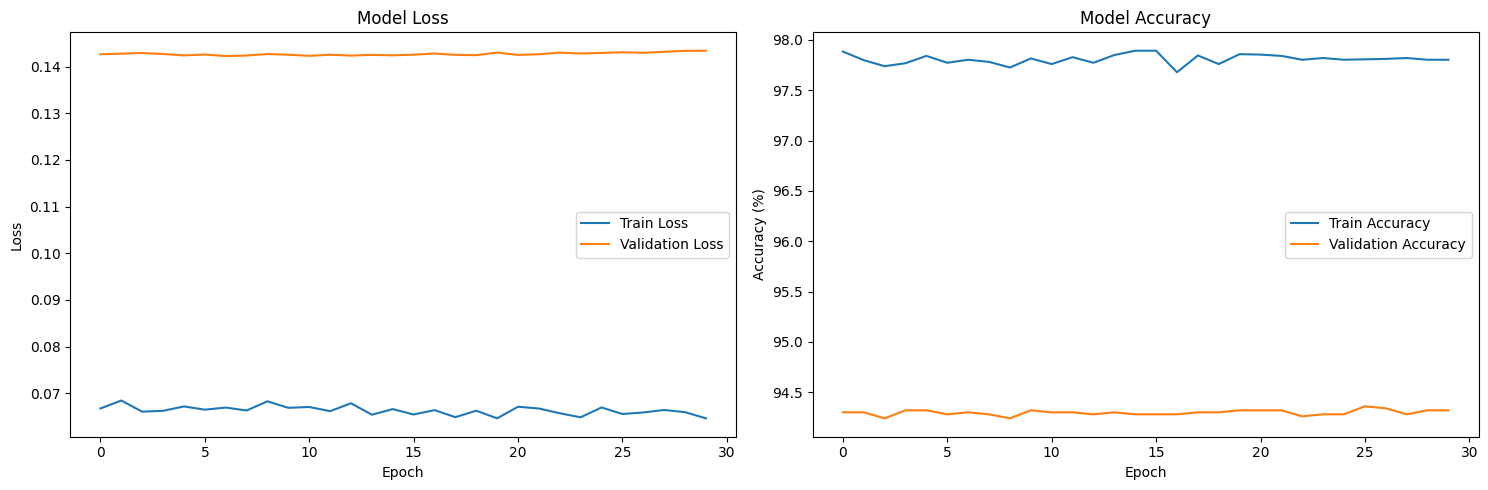

<Figure size 640x480 with 0 Axes>

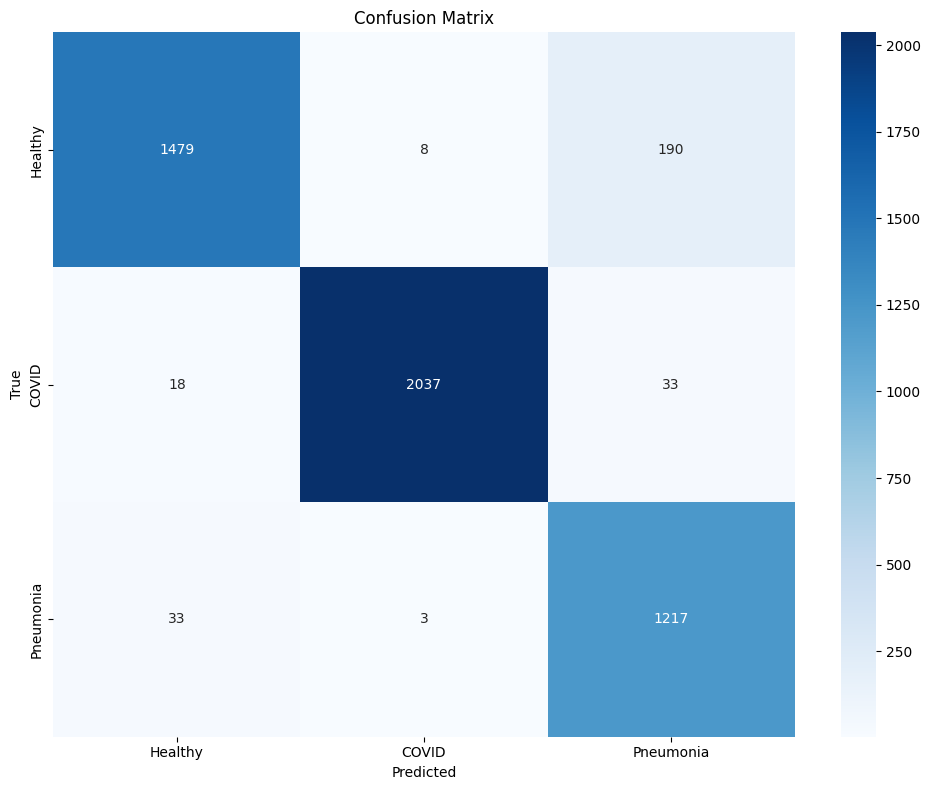

<Figure size 640x480 with 0 Axes>

In [66]:
# Train the model and get history
history, trained_model = train_model(model, train_loader, test_loader)

# Plot training metrics
plot_metrics(history)

# Plot confusion matrix
plot_confusion_matrix(trained_model, test_loader)

In [85]:
import torch
import torch.nn as nn
import torch.nn.functional as F  # Add this import
import os
import subprocess
from torchviz import make_dot
from IPython.display import Image, display

def visualize_model_architecture():
    import os
    import subprocess
    from torchviz import make_dot
    from IPython.display import Image, display

    sample_input = torch.randn(1, 1, 224, 224).to(device)
    output = model(sample_input)

    # First, verify Graphviz installation
    try:
        # Generate the dot file first
        dot = make_dot(output, 
                      params=dict(model.named_parameters()),
                      show_attrs=True,
                      show_saved=True)
        
        # Explicitly set the Graphviz path
        dot.engine = r'C:\Program Files\Graphviz\bin\dot.exe'
        
        # Save with both dot and png formats
        dot.format = 'png'
        dot.render('model_architecture', view=False)
        
        # Display the image
        display(Image(filename='model_architecture.png'))
        
        # Print model summary using forward hooks to track dimensions
        print("\nModel Architecture Summary:")
        print("-" * 50)
        print(model)
        
        # Track dimensions through layers using hooks
        activation = {}
        def get_activation(name):
            def hook(model, input, output):
                activation[name] = output.shape
            return hook
        
        # Register hooks for each layer
        handles = []
        for name, layer in model.named_modules():
            if not isinstance(layer, nn.Sequential):
                handles.append(layer.register_forward_hook(get_activation(name)))
        
        # Forward pass to trigger hooks
        _ = model(sample_input)
        
        # Print dimensions
        print("\nLayer Dimensions:")
        print("-" * 50)
        for name, shape in activation.items():
            print(f"{name}: output shape = {shape}")
        
        # Remove hooks
        for handle in handles:
            handle.remove()
        
        # Print total parameters
        total_params = sum(p.numel() for p in model.parameters())
        print(f"\nTotal Parameters: {total_params:,}")
        
    except Exception as e:
        print(f"Error during visualization: {e}")
        print("\nFalling back to text-based visualization...")
        
        # Fallback visualization
        print("\nModel Structure:")
        print("-" * 50)
        summary = []
        def hook_fn(module, input, output):
            summary.append(f"{module.__class__.__name__}:")
            summary.append(f"  Input shape:  {input[0].shape}")
            summary.append(f"  Output shape: {output.shape}")
            summary.append(f"  Parameters:   {sum(p.numel() for p in module.parameters()):,}")
        
        handles = []
        for layer in model.children():
            handles.append(layer.register_forward_hook(hook_fn))
        
        _ = model(sample_input)
        
        for line in summary:
            print(line)
            
        for handle in handles:
            handle.remove()

# Initialize model and run visualization
model = Network().to(device)
visualize_model_architecture()

Error during visualization: unknown engine: 'c:\\program files\\graphviz\\bin\\dot.exe' (must be one of ['circo', 'dot', 'fdp', 'neato', 'osage', 'patchwork', 'sfdp', 'twopi'])

Falling back to text-based visualization...

Model Structure:
--------------------------------------------------
Conv2d:
  Input shape:  torch.Size([1, 1, 224, 224])
  Output shape: torch.Size([1, 16, 224, 224])
  Parameters:   160
MaxPool2d:
  Input shape:  torch.Size([1, 16, 224, 224])
  Output shape: torch.Size([1, 16, 112, 112])
  Parameters:   0
Conv2d:
  Input shape:  torch.Size([1, 16, 112, 112])
  Output shape: torch.Size([1, 32, 112, 112])
  Parameters:   4,640
MaxPool2d:
  Input shape:  torch.Size([1, 32, 112, 112])
  Output shape: torch.Size([1, 32, 56, 56])
  Parameters:   0
Conv2d:
  Input shape:  torch.Size([1, 32, 56, 56])
  Output shape: torch.Size([1, 64, 56, 56])
  Parameters:   18,496
MaxPool2d:
  Input shape:  torch.Size([1, 64, 56, 56])
  Output shape: torch.Size([1, 64, 28, 28])
  Paramete

In [17]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
# Define your model's architecture data
layers = [
    {"name": "Input", "type": "Input", "output_shape": [1, 224, 224], "params": 0, "color": "#FFD700"},
    {"name": "Conv2d (16)", "type": "Conv", "output_shape": [16, 224, 224], "params": 160, "color": "#FF6347"},
    {"name": "AvgPool2d", "type": "Pool", "output_shape": [16, 112, 112], "params": 0, "color": "#4682B4"},
    {"name": "Conv2d (32)", "type": "Conv", "output_shape": [32, 112, 112], "params": 4640, "color": "#FF6347"},
    {"name": "AvgPool2d", "type": "Pool", "output_shape": [32, 56, 56], "params": 0, "color": "#4682B4"},
    {"name": "Conv2d (64)", "type": "Conv", "output_shape": [64, 56, 56], "params": 18496, "color": "#FF6347"},
    {"name": "AvgPool2d", "type": "Pool", "output_shape": [64, 28, 28], "params": 0, "color": "#4682B4"},
    {"name": "Flatten", "type": "Flatten", "output_shape": [50176], "params": 0, "color": "#9370DB"},
    {"name": "Linear (512)", "type": "FC", "output_shape": [512], "params": 25690624, "color": "#32CD32"},
    {"name": "Dropout", "type": "Dropout", "output_shape": [512], "params": 0, "color": "#BA55D3"},
    {"name": "Linear (128)", "type": "FC", "output_shape": [128], "params": 65664, "color": "#32CD32"},
    {"name": "Dropout", "type": "Dropout", "output_shape": [128], "params": 0, "color": "#BA55D3"},
    {"name": "Output (3)", "type": "Output", "output_shape": [3], "params": 387, "color": "#FF4500"},
]

# Create the figure
fig = make_subplots(rows=1, cols=2, specs=[[{"type": "xy"}, {"type": "table"}]], horizontal_spacing=0.3,column_widths=[0.8, 0.2])

# Add architecture blocks
for i, layer in enumerate(layers):
    fig.add_trace(
        go.Scatter(
            x=[i*3] * 3,  # Keep tripled spacing between layers
            y=[-0.6, 0.5, 1.7],  # Adjusted y-positions for better spacing
            mode="lines+markers+text",
            line=dict(width=40, color=layer["color"]),
            marker=dict(size=0),
            text=[f"<b>{layer['name']}</b>", 
                  f"S: {layer['output_shape']}", 
                  f"Params: {layer['params']:,}"],
            textposition=["middle left",   # Bottom label aligned left
                         "middle center",  # Middle label centered
                         "middle left"],   # Top label aligned left
            textfont=dict(size=10),
            hoverinfo="text",
            name=layer["name"],
        ),
        row=1, col=1
    )

# Add parameter table
table_data = [
    ["<b>Layer</b>"] + [layer["name"] for layer in layers],
    ["<b>Type</b>"] + [layer["type"] for layer in layers],
    ["<b>Output Shape</b>"] + [str(layer["output_shape"]) for layer in layers],
    ["<b>Parameters</b>"] + [f"{layer['params']:,}" for layer in layers],
]

fig.add_trace(
    go.Table(
        header=dict(
            values=["<b>Category</b>"] + [f"Layer {i+1}" for i in range(len(layers))],
            align="left",
            fill_color="#2F4F4F",
            font=dict(color="white", size=8)
        ),
        cells=dict(
            values=table_data,
            align="left",
            fill_color=["#F0F8FF", "#FFFFFF"],
            font_size=10,
            height=30  # Increased cell height
        )
    ),
    row=1, col=2
)

# Style the plot
fig.update_layout(
    title={
        'text': "<b>CNN Architecture Visualization</b><br>Input Shape: [1, 1, 224, 224]",
        'y': 0.98,
        'x': 0.5,
        'xanchor': 'center',
        'yanchor': 'top',
        'font': dict(size=24)  # Increased title size
    },
    xaxis=dict(
        showgrid=False, 
        zeroline=False, 
        visible=False, 
        range=[-3, len(layers)*3]  # Adjusted range for wider spacing
    ),
    yaxis=dict(
        showgrid=False, 
        zeroline=False, 
        visible=False, 
        range=[-1.0, 2.2]  # Adjusted range for new label positions
    ),
    plot_bgcolor="white",
    showlegend=False,
    width=2500,  # Increased overall width
    height=1200,  # Increased overall height
    margin=dict(
        l=50,  # Increased left margin
        r=100,  # Increased right margin
        t=200,  # Increased top margin
        b=100   # Increased bottom margin
    ),
    annotations=[
        dict(
            text=f"<b>Total Parameters: {sum(layer['params'] for layer in layers):,}</b>",
            x=0.5, 
            y=1.12,  # Moved total parameters text higher
            xref="paper", 
            yref="paper",
            showarrow=False,
            font=dict(size=18)
        )
    ]
)

# Add layer type legend
layer_types = set(layer["type"] for layer in layers)
for i, ltype in enumerate(layer_types):
    fig.add_annotation(
        x=0.01,
        y=0.95 - (i*0.1),  # Increased spacing between legend items
        xref="paper", 
        yref="paper",
        text=f"■ {ltype}",
        font=dict(
            color=[layer["color"] for layer in layers if layer["type"] == ltype][0],
            size=16  # Increased legend text size
        ),
        showarrow=False
    )

# Save and show the figure
fig.write_html("model_architecture.html")

fig.show()

In [95]:
!pip install nbformat>=4.2.0 plotly


[notice] A new release of pip is available: 24.0 -> 25.0.1
[notice] To update, run: C:\Users\anmol\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip
